# Model discrepancy with a Gaussian process

Our model is always wrong somewhere.  When it is wrong in a *structured* way —
smoothly, as a function of $x$, rather than point by point — the residuals it
leaves are correlated, and a covariance that assumes independence will read
those correlations as precision it does not have.

The standard treatment is [Kennedy & O'Hagan
(2001)](https://doi.org/10.1111/1467-9868.00294), who add a discrepancy term to
the model.  There are two quite different things people mean by that:

- a **mean-zero discrepancy**, which learns only the *covariance* of the
  mismatch: we say the truth departs smoothly from our model by some amount, we
  say how far and how smoothly, and we integrate over every such departure;
- a **non-zero-mean discrepancy**, which gives the mismatch its own parameters
  and builds a posterior for the discrepancy function itself (recipes 8 and 36).

This notebook is entirely about the first.  We will also give the discrepancy an
amplitude that **grows with $x$**, because that is genuine prior knowledge here:
our data look like a line at small $x$ and stop looking like one further out.

Recipes: 7

In [1]:
import corner
import dynesty
import emcee
import jitr
import matplotlib.pyplot as plt
import numpy as np
import plotstyle
from jitr.optical_potentials.potential_forms import (
    thomas_safe,
    woods_saxon_prime_safe,
    woods_saxon_safe,
)
from scipy import stats
from sklearn.gaussian_process.kernels import Matern, WhiteKernel

import rxmc as rx
from rxmc import terms as T
from rxmc import transforms as tf

plotstyle.use()

## A line, and a truth that leaves it

Our truth is a line plus a small quadratic departure, $0.03\,x^2$.  At the left
edge that defect is 0.001, far below the 0.02 noise and quite invisible; by
$x = 5$ it is 0.75, thirty-seven times the error bar.  A straight-line model is
therefore excellent at small $x$ and hopeless at large $x$, which is exactly the
situation the growing amplitude is meant to express.

In [2]:
M_TRUE, B_TRUE = 0.8, 1.0


def defect(x):
    return 0.03 * np.asarray(x, dtype=float) ** 2


def truth(x):
    return M_TRUE * np.asarray(x, dtype=float) + B_TRUE + defect(x)


rng = np.random.default_rng(7)
x = np.linspace(0.2, 5.0, 30)
noise = 0.02
data = rx.Dataset(
    x, truth(x) + rng.normal(0.0, noise, x.size), np.full(x.size, noise), label="toy"
)
x_fine = np.linspace(0.0, 6.0, 80)
print(
    "defect / noise at x = 0.2, 2.5, 5.0:", np.round(defect([0.2, 2.5, 5.0]) / noise, 1)
)

defect / noise at x = 0.2, 2.5, 5.0: [ 0.1  9.4 37.5]


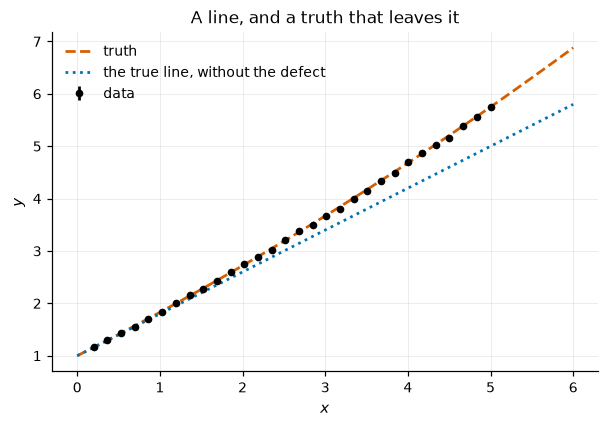

In [3]:
fig, ax = plt.subplots()
ax.errorbar(data.x, data.y, data.y_err, fmt="o", ms=4, color="k", label="data")
ax.plot(x_fine, truth(x_fine), "--", color=plotstyle.COLOURS[1], label="truth")
ax.plot(
    x_fine,
    M_TRUE * x_fine + B_TRUE,
    ":",
    color=plotstyle.COLOURS[0],
    label="the true line, without the defect",
)
ax.set(xlabel="$x$", ylabel="$y$", title="A line, and a truth that leaves it")
ax.legend()
plt.show()

## Four ways to say "the model is wrong"

We fit the same line four times, changing only the covariance:

1. **statistics only** — the reported errors, and nothing else;
2. **a diagonal model error** (`T.model_error`) — every point gets extra,
   *independent* slack;
3. **a GP with a constant amplitude** — a smooth mean-zero discrepancy of the
   same size everywhere;
4. **a GP with an amplitude growing in $x$** (`T.exp_growth_amplitude`) — the
   same, but allowed to be small where we trust the line and large where we do
   not.

Only the last one encodes what we actually believe.  All four are one `Term` in
a `Constraint`, and the inference code does not change between them.

In [4]:
m = rx.Parameter("m", prior=stats.norm(0.0, 2.0), latex="m")
b = rx.Parameter("b", prior=stats.norm(0.0, 2.0), latex="b")
line = rx.Model(lambda x, m, b: m * x + b, [m, b])
comp = rx.Comparison(data, line)

gamma = rx.Parameter(
    "log_gamma", prior=stats.norm(np.log(0.05), 1.0), latex=r"\log\gamma"
)
log_A = rx.Parameter("log_A", prior=stats.norm(np.log(0.02), 1.5), latex=r"\log A")
amp_slope = rx.Parameter("amp_slope", prior=stats.norm(1.0, 1.0), latex=r"s_A")
log_ell = rx.Parameter("log_ell", prior=stats.norm(0.5, 1.0), latex=r"\log \ell")

kernel = Matern(length_scale=2.0, nu=2.5) + WhiteKernel(1e-6, "fixed")
gp_const = T.kernel(
    kernel, params=[log_ell], amplitude=T.constant_amplitude, amplitude_params=(log_A,)
)
gp_grow = T.kernel(
    kernel,
    params=[log_ell],
    amplitude=T.exp_growth_amplitude(5.0),
    amplitude_params=(log_A, amp_slope),
)

In [5]:
problems = {
    "statistics only": rx.Problem([rx.Constraint([comp])]),
    "diagonal model error": rx.Problem(
        [rx.Constraint([comp], terms=[T.model_error(gamma)])]
    ),
    "GP, constant amplitude": rx.Problem([rx.Constraint([comp], terms=[gp_const])]),
    "GP, growing amplitude": rx.Problem([rx.Constraint([comp], terms=[gp_grow])]),
}
for name, p in problems.items():
    print(f"{name:24s} {p.names}")

statistics only          ['m', 'b']
diagonal model error     ['m', 'b', 'log_gamma']
GP, constant amplitude   ['m', 'b', 'log_ell', 'log_A']
GP, growing amplitude    ['m', 'b', 'log_ell', 'log_A', 'amp_slope']


In [6]:
def fit(problem, seed, n_walkers=24, n_steps=3000):
    sampler = emcee.EnsembleSampler(n_walkers, problem.ndim, problem.log_posterior)
    sampler.random_state = np.random.RandomState(seed).get_state()
    sampler.run_mcmc(problem.sample_prior(n_walkers, rng=seed), n_steps, progress=False)
    return sampler.get_chain(discard=n_steps // 3, thin=5, flat=True)


samples = {name: fit(p, seed=i) for i, (name, p) in enumerate(problems.items())}

In [7]:
for name, p in problems.items():
    s = samples[name]
    cm, cb = p.columns(m)[0], p.columns(b)[0]
    pull_m = (s[:, cm].mean() - M_TRUE) / s[:, cm].std()
    pull_b = (s[:, cb].mean() - B_TRUE) / s[:, cb].std()
    print(
        f"{name:24s} m = {s[:, cm].mean():.3f} +/- {s[:, cm].std():.3f} "
        f"(pull {pull_m:+5.1f})   b = {s[:, cb].mean():.3f} +/- {s[:, cb].std():.3f} "
        f"(pull {pull_b:+5.1f})"
    )

statistics only          m = 0.953 +/- 0.003 (pull +60.2)   b = 0.858 +/- 0.007 (pull -19.0)
diagonal model error     m = 0.775 +/- 1.043 (pull  -0.0)   b = 0.154 +/- 2.262 (pull  -0.4)
GP, constant amplitude   m = 0.959 +/- 0.062 (pull  +2.6)   b = 1.046 +/- 0.366 (pull  +0.1)
GP, growing amplitude    m = 0.830 +/- 0.071 (pull  +0.4)   b = 0.941 +/- 0.165 (pull  -0.4)


### What those four rows say

**Statistics only** is the cautionary one: $m = 0.953 \pm 0.003$, sixty standard
deviations from the truth.  The line has no way to say "I am wrong at large
$x$", so it tilts to chase the defect and then reports a precision of three parts
in a thousand.  This is what an unmodelled discrepancy does — it does not widen
the answer, it moves it, confidently.

**The diagonal model error** covers the truth, but look at how: $m = 0.775 \pm
1.043$.  Independent slack per point can only inflate, and to cover a coherent
departure it has to inflate until the slope means nothing at all.

**The constant-amplitude GP** knows the defect is smooth, and that already helps
a great deal — $m = 0.959 \pm 0.062$ against sixty sigma before.  But it is still
2.6 sigma out, because one amplitude has to serve both ends of the range: large
enough for $x = 5$, and therefore far too generous at $x = 0.2$, where it lets
the fit off the hook exactly where the data are informative.

**The growing amplitude** is the one that matches what we believe, and it lands
on the truth: $m = 0.830 \pm 0.071$, $b = 0.941 \pm 0.165$, both within half a
sigma.  The fit also tells us it needed the growth: the inferred slope of the
amplitude is about $+1.8$, not zero.

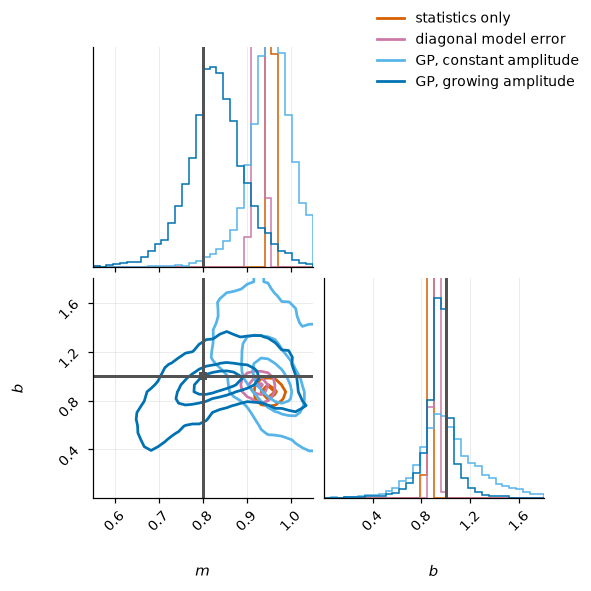

In [8]:
fig = None
colours = [plotstyle.COLOURS[i] for i in (1, 3, 5, 0)]
for (name, p), colour in zip(problems.items(), colours):
    fig = corner.corner(
        samples[name][:, p.columns(line.params)],
        fig=fig,
        labels=["$m$", "$b$"],
        truths=[M_TRUE, B_TRUE],
        range=[(0.55, 1.05), (0.0, 1.8)],
        **plotstyle.corner_kwargs(
            color=colour, fill_contours=False, plot_density=False, show_titles=False
        ),
    )
fig.legend(
    handles=[plt.Line2D([], [], color=c, label=n) for n, c in zip(problems, colours)],
    loc="upper right",
    fontsize=9,
)
plt.show()

## Propagating the whole uncertainty

The line's own band cannot bend: it is two parameters, so it is a pencil of
straight lines.  `total_predictive_band` conditions the GP on the residuals at
each posterior row, predicts the discrepancy on whatever grid we ask for, and
adds it.  Everything the problem declared is propagated, and we never have to
tell it which columns belong to the kernel.

In [9]:
def mean_band(problem, samples_, levels=(16, 84)):
    on_fine = line.bind(x_fine)
    cols = problem.columns(line.params)
    return rx.predictive.predictive_band(
        [on_fine(*s[cols]) for s in samples_[::10]], levels=levels
    )


band_gp = rx.predictive.total_predictive_band(
    problems["GP, growing amplitude"],
    gp_grow,
    line.bind(x_fine),
    x_fine,
    samples["GP, growing amplitude"],
    rng=4,
)

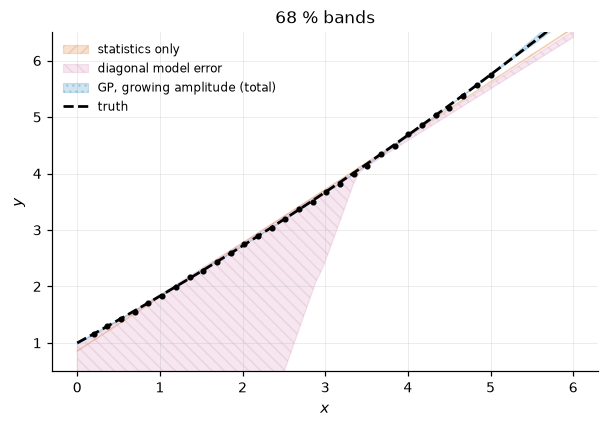

In [10]:
fig, ax = plt.subplots()
for name, colour, hatch in (
    ("statistics only", plotstyle.COLOURS[1], plotstyle.HATCHES[0]),
    ("diagonal model error", plotstyle.COLOURS[3], plotstyle.HATCHES[1]),
):
    lo, hi = mean_band(problems[name], samples[name])
    plotstyle.band(ax, x_fine, lo, hi, color=colour, hatch=hatch, label=name)
plotstyle.band(
    ax,
    x_fine,
    *band_gp,
    color=plotstyle.COLOURS[0],
    hatch=plotstyle.HATCHES[2],
    label="GP, growing amplitude (total)",
)
ax.plot(x_fine, truth(x_fine), "--", color="k", label="truth")
ax.errorbar(data.x, data.y, data.y_err, fmt="o", ms=3, color="k")
ax.set(xlabel="$x$", ylabel="$y$", title="68 % bands", ylim=(0.5, 6.5))
ax.legend(fontsize=8)
plt.show()

## What the GP actually learned

Because this is synthetic data we know the defect exactly: it is $0.03\,x^2$.
So we can condition the GP on the residuals of the posterior-median line and
hold the result up against the truth.  The interesting part is the edges — how
the GP interpolates between points, and how it relaxes back towards zero where
there are no data to hold it.

In [11]:
# the discrepancy is the total band minus the line: total_predictive_band
# knows about the growing amplitude, which the bare kernel object does not
p_grow = problems["GP, growing amplitude"]
theta_gp = np.median(samples["GP, growing amplitude"], axis=0)
line_median = line.bind(x_fine)(*theta_gp[p_grow.columns(line.params)])
disc_lo, disc_hi = band_gp[0] - line_median, band_gp[1] - line_median
true_defect = truth(x_fine) - line_median
resid = data.y - line.bind(x)(*theta_gp[p_grow.columns(line.params)])

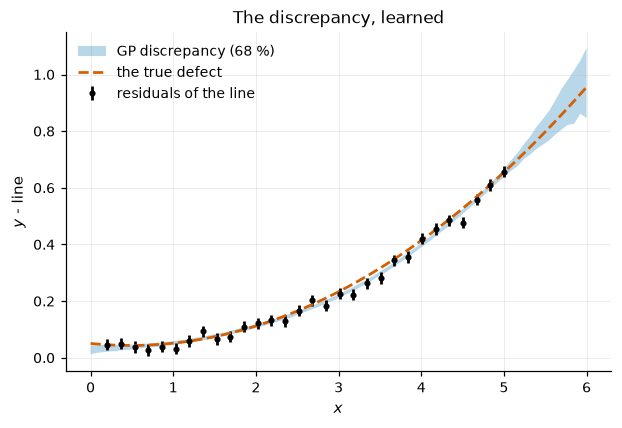

In [12]:
fig, ax = plt.subplots()
ax.errorbar(x, resid, noise, fmt="o", ms=3, color="k", label="residuals of the line")
plotstyle.band(
    ax,
    x_fine,
    disc_lo,
    disc_hi,
    color=plotstyle.COLOURS[0],
    label="GP discrepancy (68 %)",
)
ax.plot(x_fine, true_defect, "--", color=plotstyle.COLOURS[1], label="the true defect")
ax.set(xlabel="$x$", ylabel="$y$ - line", title="The discrepancy, learned")
ax.legend()
plt.show()

## The same thing on a cross section

Now a real model with a real piece of physics missing.  We generate mock
$n + {}^{40}\mathrm{Ca}$ elastic scattering at 14.1 MeV from a potential with
**volume and surface** absorption, and then fit it with a potential that has
only volume absorption.  The missing surface term is our structured defect.

Two differences from the toy.  We compare in log space, so the discrepancy is a
*fractional* defect in angle, and we drive the fit with
[dynesty](https://dynesty.readthedocs.io/) rather than emcee: optical-model
posteriors are correlated and often multimodal, and an affine-invariant ensemble
mixes poorly on them.

This half gets its own random generator, so that changing anything in the toy
above leaves the cross-section data untouched.

In [13]:
rng_xs = np.random.default_rng(2024)
reaction = jitr.reactions.ElasticReaction(target=(40, 20), projectile=(1, 0))
E_lab = 14.1
R40 = 40 ** (1 / 3)
mso = 1.0 / jitr.utils.constants.WAVENUMBER_PION


def full_central(r, Vv, Wv, Rv, av, Wd, Rd, ad):
    return -(Vv + 1j * Wv) * woods_saxon_safe(r, Rv, av) - 1j * Wd * (
        -4 * ad
    ) * woods_saxon_prime_safe(r, Rd, ad)


def volume_central(r, Vv, Wv, Rv, av):
    return -(Vv + 1j * Wv) * woods_saxon_safe(r, Rv, av)


def spin_orbit(r, Vso, Rso, aso):
    return Vso * mso**2 * thomas_safe(r, Rso, aso)


so_args = (6.0, 1.1 * R40, 0.45)
full_truth = np.array([48.0, 3.5, 1.1 * R40, 0.7, 21.0, 1.2 * R40, 0.5])
volume_truth = full_truth[:4]

In [14]:
full_params = [
    rx.Parameter(n, prior=stats.norm(0, 1))
    for n in ("Vv", "Wv", "Rv", "av", "Wd", "Rd", "ad")
]
omp_full = rx.reactions.ElasticXS(
    "dXS/dA",
    full_central,
    spin_orbit,
    lambda ws, *x: (tuple(x), so_args),
    full_params,
    lmax=10,
)
volume_params = [
    rx.Parameter("Vv", prior=stats.norm(48.0, 8.0), latex="V_v"),
    rx.Parameter("Wv", prior=stats.norm(4.0, 4.0), bounds=(0.0, 30.0), latex="W_v"),
    rx.Parameter("Rv", prior=stats.norm(1.15 * R40, 0.2), latex="R_v"),
    rx.Parameter("av", prior=stats.norm(0.65, 0.1), bounds=(0.3, 1.2), latex="a_v"),
]
omp_vol = rx.reactions.ElasticXS(
    "dXS/dA",
    volume_central,
    spin_orbit,
    lambda ws, *x: (tuple(x), so_args),
    volume_params,
    lmax=10,
)

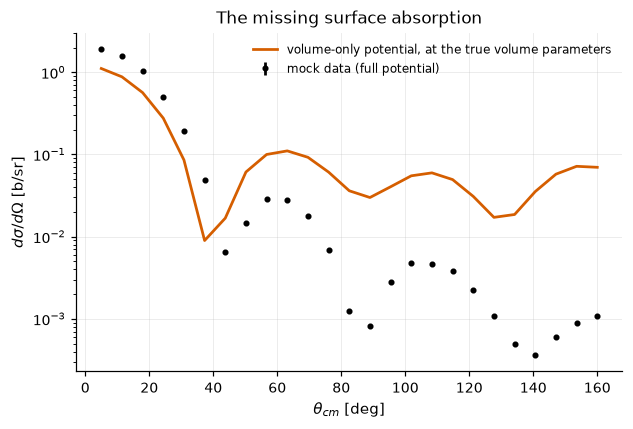

In [15]:
angles = np.deg2rad(np.linspace(5.0, 160.0, 25))
meta = {"reaction": reaction, "Elab": E_lab}
y_full = omp_full.bind(angles, meta)(*full_truth)
y_xs = y_full * (1 + rng_xs.normal(0.0, 0.04, angles.size))
d_xs = rx.Dataset(angles, y_xs, 0.04 * y_xs, label="n+40Ca 14.1 MeV", meta=meta)

fig, ax = plt.subplots()
ax.errorbar(
    np.rad2deg(angles),
    d_xs.y,
    d_xs.y_err,
    fmt="o",
    ms=3,
    color="k",
    label="mock data (full potential)",
)
ax.plot(
    np.rad2deg(angles),
    omp_vol.bind(angles, meta)(*volume_truth),
    color=plotstyle.COLOURS[1],
    label="volume-only potential, at the true volume parameters",
)
ax.set(
    xlabel=r"$\theta_{cm}$ [deg]",
    ylabel=r"$d\sigma/d\Omega$ [b/sr]",
    yscale="log",
    title="The missing surface absorption",
)
ax.legend(fontsize=8)
plt.show()

### The same three rungs

Bare, a diagonal model error, and a mean-zero GP whose amplitude grows with
angle — the same prior belief as in the toy, that the model is trustworthy
forward and suspect backward.

In [16]:
comp_xs = rx.Comparison(d_xs, omp_vol, space=tf.log)
xs_gamma = rx.Parameter(
    "log_gamma_xs", prior=stats.norm(np.log(0.05), 1.0), latex=r"\log\gamma"
)
xs_amp = rx.Parameter("log_A_xs", prior=stats.norm(np.log(0.05), 1.5), latex=r"\log A")
xs_slope = rx.Parameter("amp_slope_xs", prior=stats.norm(1.0, 1.0), latex=r"s_A")
xs_ell = rx.Parameter("log_ell_xs", prior=stats.norm(-0.5, 1.0), latex=r"\log \ell")
gp_xs = T.kernel(
    Matern(0.5, nu=2.5) + WhiteKernel(1e-6, "fixed"),
    params=[xs_ell],
    amplitude=T.exp_growth_amplitude(np.pi),
    amplitude_params=(xs_amp, xs_slope),
)
xs_problems = {
    "bare": rx.Problem([rx.Constraint([comp_xs])]),
    "diagonal model error": rx.Problem(
        [rx.Constraint([comp_xs], terms=[T.model_error(xs_gamma)])]
    ),
    "GP, growing amplitude": rx.Problem([rx.Constraint([comp_xs], terms=[gp_xs])]),
}

In [17]:
def nested(problem, seed, nlive=150):
    sampler = dynesty.NestedSampler(
        problem.log_likelihood,
        problem.prior_transform,
        problem.ndim,
        nlive=nlive,
        sample="rwalk",
        rstate=np.random.default_rng(seed),
    )
    sampler.run_nested(dlogz=0.5, print_progress=False)
    res = sampler.results
    print(
        f"log Z = {res.logz[-1]:8.2f} +/- {res.logzerr[-1]:.2f}, "
        f"{int(np.sum(res.ncall)):7d} likelihood calls"
    )
    return res.samples_equal(rstate=np.random.default_rng(seed))


xs_samples = {}
for i, (name, p) in enumerate(xs_problems.items()):
    print(f"{name:22s}", end=" ")
    xs_samples[name] = nested(p, 10 + i)

bare                   

log Z =  -581.75 +/- 0.64,   85485 likelihood calls
diagonal model error   

log Z =   -19.61 +/- 0.50,   64449 likelihood calls
GP, growing amplitude  

log Z =    -9.93 +/- 0.52,   75404 likelihood calls


In [18]:
for name, p in xs_problems.items():
    s = xs_samples[name][:, p.columns(volume_params)]
    print(
        f"{name:22s} "
        + "  ".join(
            f"{q.name}={s[:, k].mean():6.2f}+/-{s[:, k].std():.2f}"
            for k, q in enumerate(volume_params)
        )
        + "   max|pull| = "
        + f"{max(abs((s[:, k].mean() - volume_truth[k]) / s[:, k].std()) for k in range(4)):.1f}"
    )

bare                   Vv= 26.85+/-0.41  Wv= 16.64+/-0.23  Rv=  4.43+/-0.02  av=  0.66+/-0.01   max|pull| = 56.7
diagonal model error   Vv= 38.78+/-3.47  Wv= 18.91+/-1.37  Rv=  4.28+/-0.15  av=  0.56+/-0.06   max|pull| = 11.3
GP, growing amplitude  Vv= 43.67+/-1.42  Wv= 13.61+/-1.07  Rv=  4.29+/-0.06  av=  0.48+/-0.02   max|pull| = 9.5


### What the three rungs did to the potential

The evidence is blunt about it.  Log $Z$ goes from $-581.75$ for the bare fit to
$-19.61$ once we allow a diagonal model error, and $-9.93$ with the GP.  A gap
of that size is not a preference, it is a verdict: the bare fit's claim that the
reported 4 % errors explain every disagreement is simply false, and the sampler
can tell.

The parameters follow the same order.  The bare fit puts $V_v$ at
$26.9 \pm 0.4$ MeV where the truth is 48 — wrong by fifty standard deviations,
and confident.  The model error widens until nothing is precise.  The GP
recovers $V_v$ to $43.7 \pm 1.4$, about three sigma from the truth, while
keeping useful width.

But look at $W_v$: $13.6 \pm 1.1$ against a truth of 3.5, nine sigma out, in
*every* rung including the GP.  That is not a failure of the discrepancy model,
it is the physics.  The data were generated with volume **and** surface
absorption; we fitted a potential with only volume absorption, and at a single
energy those two shapes are very hard to tell apart.  The fitted volume
absorption is quite literally absorbing the missing surface term.

This is the honest limit of the method, and it is worth stating plainly: a
discrepancy model widens what we do not know, and stops the fit from lying about
its precision.  It does not recover information the measurement never contained.

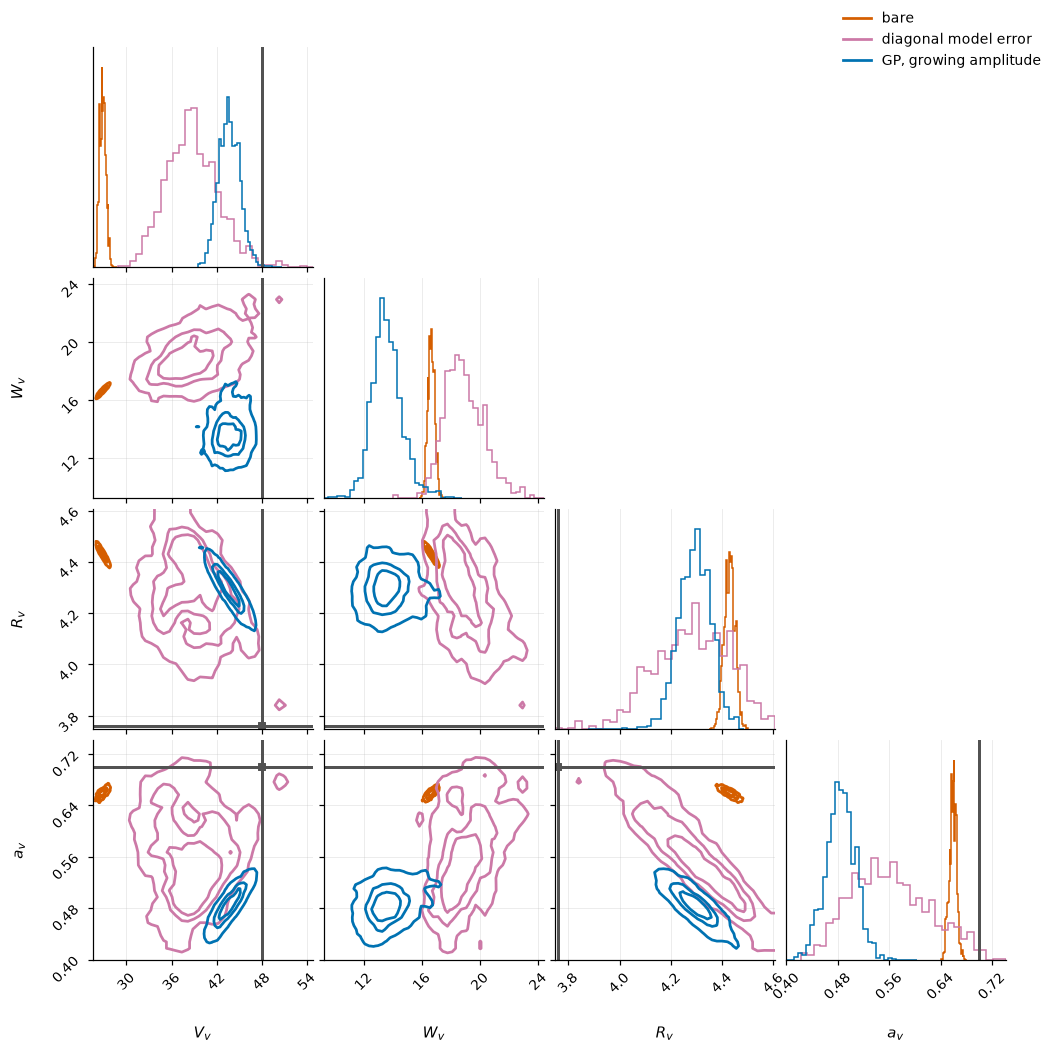

In [19]:
labels = [f"${q.latex}$" for q in volume_params]
fig = None
xs_colours = [plotstyle.COLOURS[i] for i in (1, 3, 0)]
for (name, p), colour in zip(xs_problems.items(), xs_colours):
    fig = corner.corner(
        xs_samples[name][:, p.columns(volume_params)],
        fig=fig,
        labels=labels,
        truths=volume_truth,
        **plotstyle.corner_kwargs(
            color=colour, fill_contours=False, plot_density=False, show_titles=False
        ),
    )
fig.legend(
    handles=[
        plt.Line2D([], [], color=c, label=n) for n, c in zip(xs_problems, xs_colours)
    ],
    loc="upper right",
    fontsize=9,
)
plt.show()

### The learned discrepancy against the missing physics

The defect the GP has to describe is the log ratio of the full potential that
generated the data to the volume-only one we fitted.  We draw it at the
posterior-median volume parameters, on a finer angular grid than the data, so we
can see how the GP interpolates between points and how it behaves beyond them.

In [20]:
p_xs_gp = xs_problems["GP, growing amplitude"]
s_xs_gp = xs_samples["GP, growing amplitude"]
theta_xs = np.median(s_xs_gp, axis=0)
fine = np.deg2rad(np.linspace(2.0, 178.0, 90))
resid_xs = comp_xs.y - comp_xs.predict(*theta_xs[p_xs_gp.columns(volume_params)])

# again the total band minus the fitted model, both in log space
band_xs = rx.predictive.total_predictive_band(
    p_xs_gp, gp_xs, omp_vol.bind(fine, meta), fine, s_xs_gp, rng=5, n_draws=100
)
mu_fine = comp_xs.space(
    omp_vol.bind(fine, meta)(*theta_xs[p_xs_gp.columns(volume_params)])
)
disc_lo_xs, disc_hi_xs = band_xs[0] - mu_fine, band_xs[1] - mu_fine
true_defect_xs = np.log(omp_full.bind(fine, meta)(*full_truth)) - mu_fine

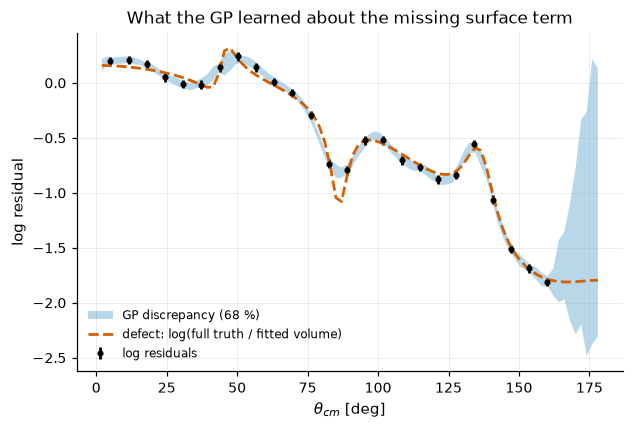

In [21]:
fig, ax = plt.subplots()
ax.errorbar(
    np.rad2deg(angles),
    resid_xs,
    comp_xs.y_err,
    fmt="o",
    ms=3,
    color="k",
    label="log residuals",
)
plotstyle.band(
    ax,
    np.rad2deg(fine),
    disc_lo_xs,
    disc_hi_xs,
    color=plotstyle.COLOURS[0],
    label="GP discrepancy (68 %)",
)
ax.plot(
    np.rad2deg(fine),
    true_defect_xs,
    "--",
    color=plotstyle.COLOURS[1],
    label="defect: log(full truth / fitted volume)",
)
ax.set(
    xlabel=r"$\theta_{cm}$ [deg]",
    ylabel="log residual",
    title="What the GP learned about the missing surface term",
)
ax.legend(fontsize=8)
plt.show()

## Takeaways

- A mean-zero GP discrepancy is just another covariance term, and
  `total_predictive_band` propagates it to any grid from the problem alone.
- An unmodelled discrepancy does not make the answer vague, it makes it *wrong
  and confident*: sixty sigma on the toy's slope.
- A diagonal model error can only inflate.  It covers the truth by making the
  parameters meaningless, because independent slack cannot describe a coherent,
  smooth departure.
- The amplitude is prior knowledge, and it is worth stating.  A constant
  amplitude has to be generous everywhere to cover the worst region; letting it
  grow with $x$ keeps the fit honest where the model is good and forgiving where
  it is not.
- None of this manufactures information.  Where the data cannot separate two
  effects — volume against surface absorption at a single energy — the
  discrepancy model widens the answer rather than pretending to resolve it.